## Tutorial 1: Rabi Oscillations in two-level system
In this tutorial we will be forgetting about all couplings into external resevoirs and only consider an isolated two-level system. This will both serve as a test and also as a way to get familiar with how to run a calculation using the code. The calculation will be done using a two-site tight-binding model. We will be recreating the plot from Fig. 43.3 on page 419 from [here](https://homes.nano.aau.dk/tgp/master_2024.pdf). The code uses sisl-geometries as input and contains the option to input the tight-binding model in sisl format, which is what we will use here.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sisl
from Zandpack.TimedependentTransport import TD_Transport, hbar, AdaptiveRK4

The needed parameters to run the calculation is defined below. The electrodes defined are purely there because the code needs them to run, but their coupling will be set to zero soon enough.

In [9]:
dipole_moment = 0.3 * hbar
w12           = 1
Rabi_f        = dipole_moment / hbar
pert_w        = 0.9
lat_const     = 2.5
geom_dev      = sisl.geom.sc(lat_const, 'H').tile(4, 0)
geom_ep       = sisl.geom.sc(lat_const, 'H').tile(1, 0).move(np.array([lat_const * 3, 0, 0]))
geom_em       = sisl.geom.sc(lat_const, 'H').tile(1, 0)

geom_dev      = geom_dev.add_vacuum(10,1).add_vacuum(10,2).add_vacuum(10,0)
geom_em       = geom_em. add_vacuum(10,1).add_vacuum(10,2)
geom_ep       = geom_ep. add_vacuum(10,1).add_vacuum(10,2)

Now we define the object (R) we will be dealing with for the most part of this tutorial. It takes the electrode geometries, the device geometry, the chemical potentials of each electrode and its temperature in electron-volt

In [10]:
#                 electrode geoms   device geom  steady state chemical potentials   Temperatures of the leads
R = TD_Transport([geom_em,geom_ep], geom_dev,    mu_i=[0.0, 0.0],                   kT_i = [0.025, 0.025])

Generally you'll have to define a grid where the self energies of the leads are sampled. This is done here with the linspace "line". "line" is stacked with itself to give an array of shape (#nleads, #samplings). The sampling do not do anything for us right now because the device-lead coupling will be neglected. It is only present so that the code will run. 

Furthermore, the second and third argument of "Make_Contour" tells the code to use 20 poles with Im[$z_i$]>0 and 20 poles with Im[$z_i$]<0 to approximate the Fermi-function using the approximation from "Padé spectrum decompositions of quantum distribution functions and optimal hierarchical equations of motion construction for quantum open systems" by Jie Hu et al. A plot of the approximation is lastly plotted. Another option is to set pole_mode = 'Croy2009', but this is just a worse approximation. 

Also, if you decrease the value of the second argument, you'll see the approximation gets worse. Checks on whenever or not this approximation is good enough are done at a later point in the calculation, and if it is not sufficient, you'll have to go back here and increase the number of poles

In [11]:
line = np.linspace(-10, 10, 30)  + 1j  * 1e-3
line = np.vstack((line,line))
R.Make_Contour(line, 20, pole_mode = 'JieHu2011'); 

Now we initialise the electrode-part of the input to TBtrans. If we where doing DFT, the "run_electrodes"-command would do the DFT calculation for the electrode electronic structure. 

We need to give many of the same inputs as when you write a .fdf file for TBtrans.

In [12]:
R.Electrodes ( semi_infs = ['-a1', '+a1'] ) # semi-infinite directions
R.make_device( elec_inds = [[0],[3]]      ) # Were the electrode sites are in the device
elec = sisl.Hamiltonian(sisl.geom.sc(lat_const, sisl.Atom(1, R= 3.0)).add_vacuum(10,1).add_vacuum(10,2))
# Electrode Hamiltonian
elec.construct([[0.1, lat_const * 1.1], 
                [0  , 20             ]])
# Run TBtrans
R.run_electrodes(manual_H = [elec, elec])


/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_lattice']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_positions']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_types']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['number']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/python3.10/site

Now we make the device electronic structure and set the coupling to the leads to zero. Furthermore, we also put in the two-level system, which is split symmetrically around zero with $E = \pm\hbar\omega_{12}/2$. $\omega_{12}$ was defined at the top as the variable w12. Lastly the TBtrans in run and the data from the TBtrans calculation is read.

(note: if you want to rerun the cell below, you'll have to remake the device, because the siesta.TBT.nc file in the directory will cause TBtbtrans to raise an error. Run the cell above to recreate)

In [13]:
dev_H = sisl.Hamiltonian(sisl.geom.sc(lat_const, sisl.Atom(1, R= 3.0)).tile(4,0).add_vacuum(10,1).add_vacuum(10,2).add_vacuum(10,0))
dev_H.construct([[0.1, lat_const * 1.1], 
                 [0,   1              ] ])

eps        = 1e-3
dev_H[0,1] = 5**0.5 * eps
dev_H[1,0] = 5**0.5 * eps
dev_H[2,3] = 5**0.5 * eps
dev_H[3,2] = 5**0.5 * eps
dev_H[1,1] = -w12*hbar/2.
dev_H[2,2] = +w12*hbar/2.
dev_H[1,2] = eps
dev_H[2,1] = eps

R.run_device(manual_H = dev_H)
R.read_data()
print(sisl.__version__)

Running TB-Trans in Directory: Device!



warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].

Calculating corrections for electrode 0. (Normal electrode)
Calculating corrections for electrode 1. (Normal electrode)

 Building ES - H - Self Energies 

[0]
Using S = S

 Overlap Included!

0.15.2


At this point in an actual calculation we would have the device region Hamiltonian together with the self-energies of the leads. Because we model a system with no leads attached, this next line doesnt influence what we are doing, but is needed for the code to work. Where the system to have some leads attached, it would fit the self-energies to a sum of Lorentzians. Right now it will just fit a self-energy that is very close to zero, as will be seen below. 

Finding Lambda matrices:

Rerun


--------------------
Optimizing Lorentzian Expansion
--------------------

1
#Variables optimized for: 6
Lorentzian fit took 0.0015263557434082031 seconds.
Finding Lambda matrices:

Rerun


--------------------
Optimizing Lorentzian Expansion
--------------------

1
#Variables optimized for: 6
Lorentzian fit took 0.001384735107421875 seconds.


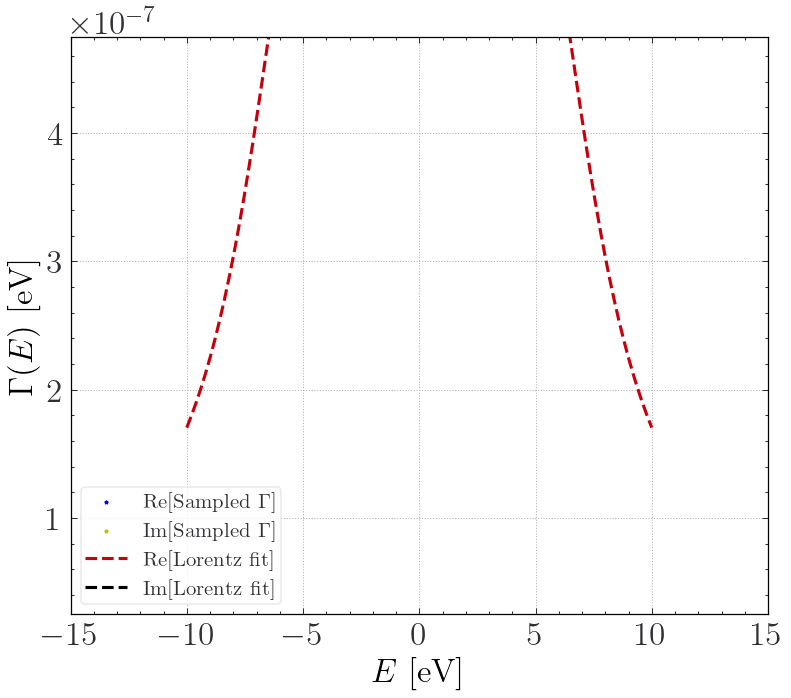

Block-matrix of the device: 
 [[1 1]
 [1 1]]


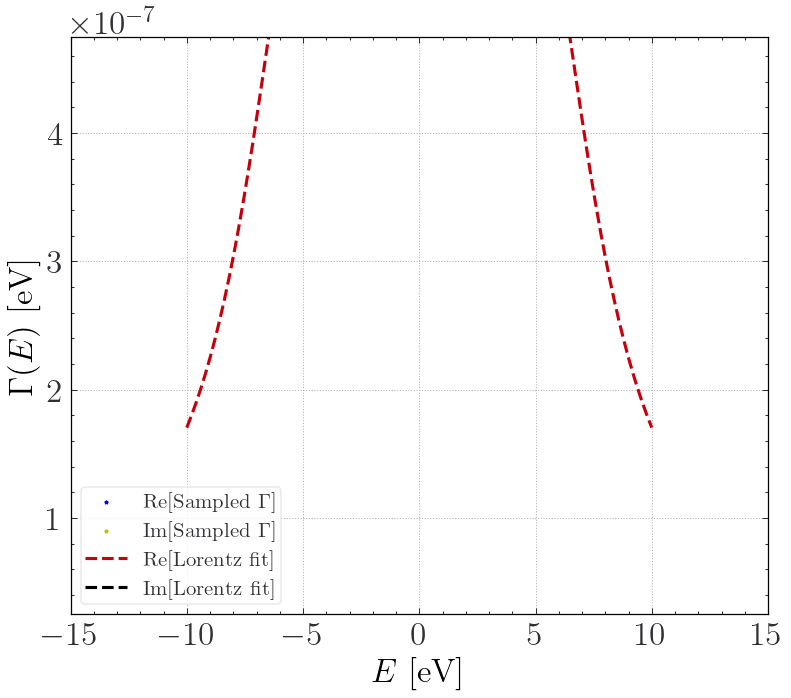

In [16]:
R.Fit()
# We plot the (0,0) self-energy matrix element in block (0,0) of lead 0
#                           (lead, Block_i, Block_j, idx_i, idx_j)
R.Inspect_Lorentzian_fit(   0,      0,      0,      0,      0, Emin = -10, Emax=10); 
plt.show()
R.Inspect_Lorentzian_fit(1,1,1,0,0,Emin = -10, Emax=10)
#plt.ylim(None,None)
#plt.show()
print('Block-matrix of the device: \n',R.BS)


In [18]:
R.tofile('Rabi')

Finding eigenvalues and eigenvectors
Maximum of eigenvalues of Lorentzian Gammas: 1e-06
Minimum of eigenvalues of Lorentzian Gammas: 0.0
If the minimum is negative, you should take extra care!
( if minimum negative Check eigenvalues of $\Gamma$)


We now have a folder called "Rabi" in the folder you're running this notebook in.
Together with the Bias.py and Initial.py files, we can run a timedependent propagation of the density matrix of this system. We simply keep the leads at the chemical potential $E=0$eV and add a dipole interaction between the upper and lower levels. 
See the Bias.py file and see the for yourself how these files should look.
The Initial.py file is for toggling flags and controlling the fineness of the ODE-solver.


Propagate it with this command:

    mpirun -np 3 zand Dir=$PWD

we can read in the density matrix (even while its propagating), and see the so-called Rabi-oscillations:


In [19]:
# We can even do the propagation from the notebook:
# Here you also need to be careful with the way
# Your threading takes place, ie. you have to 
# Make sure your # mpi-threads and #omp threads are
# set a reasonable way, eg. OMP_NUM_THEADS=1 if you have less than 6 cores
!mpirun -np 3 zand Dir=$PWD

Warning from RK4pars: Something went wrong with loading k0nfig
Warning from RK4pars: Something went wrong with loading k0nfig
Warning from RK4pars: Something went wrong with loading k0nfig

  
  ▂▃▄▅▆▇█▓▒░zand (v. 1.0)░▒▓█▇▆▅▄▃▂
  
  Program developed for time-dependent transport in nanostructures 
  at the Technical University of Denmark (DTU).
  
  Please cite this article:
       ***Cool Article Bibtex***  

  
  Author: Aleksander Bach Lorentzen, DTU ( aleksander.bach@dipc.org / aleksander.bl.mail@gmail.com )
  Supervisor: Prof. Mads Brandbyge, DTU.
    - Dr. Nick Papior from DTU compute has constributed with performance tips.
    - Dr. Alexander Croy from Friedrich Schiller University has contributed 
      with methods for consistency checks and steadystate solution. 


  Visit Github.com/AleksBL/?? for tutorials.
  
  Basic function of this program:
  There are two scripts that needs to accompany this program:
 
  The "Initial.py" script, which has the information of the 
  init

(-25.0, 160.0)

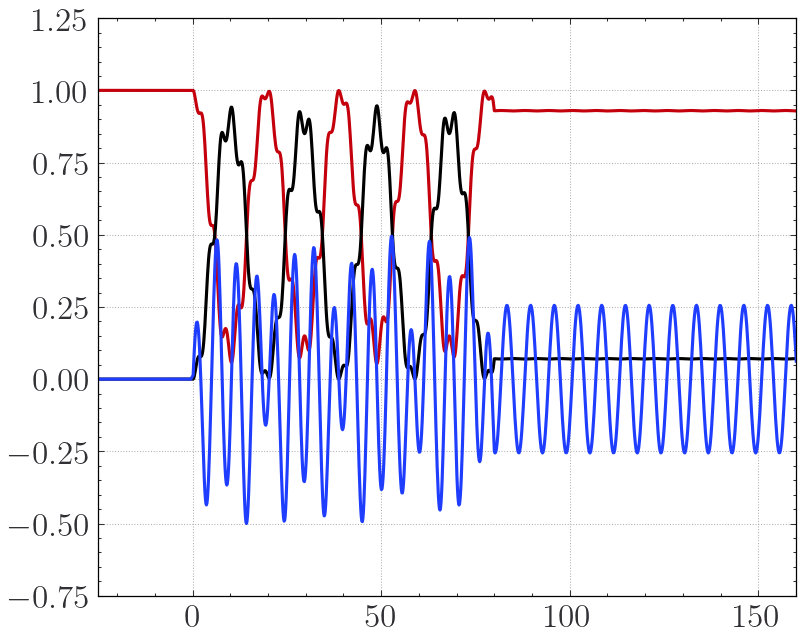

In [21]:
from Zandpack.mpi_tools import combine_dm as CDM
t,DM = CDM(['Rabi_save'])
plt.plot(t,DM[:,0,0,0])
plt.plot(t,DM[:,0,1,1])
plt.plot(t,DM[:,0,0,1].imag)
plt.xlim([-25,160])


We see on the convergence plot above that we need to put $\epsilon$ very small ($10^{-12}$ or so) to converge the the density matrix plot over time. This is a very small value compared to what we will encounter later, and it is because the auxillary modes are not differing from zero by any meaningful amount since we neglected the lead couplings. The auxillary modes will however contain many more entries than the density matrix itself. This means when we later incorporate these modes, we'll be able to converge the calculation with a larger epsilon. 

## Summary:

We've seen:

    1. Setup device and electrode geometries and pass it to the code.
    2. Define electrode and device Hamiltonians with sisl
    3. Define the timedependence of the bias in the leads and the timedependence of the Hamiltonian of the system          through the Bias.py and Initial.py files.
    


### Extra:
    Try to set "eps" in used in the creation of the device Hamiltonian to 1 instead, and see what changes. Try to plot the current over time. Change the perturbing frequency "pert_w" to see how the system responds to different frequencies. You'll need to change it in the "Bias.py" file, and you could make a loop, where the number is written to a file, and then read by the Bias.py file, which you'll also have to code. Then you can make a loop over different pert_w where the command time-dependent propagation is run in each iteration.